<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/regression_with_regularization/LinearRegressionWithPyTorchNNLayers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install hiddenlayer

In [7]:
import torch
import hiddenlayer as hl
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import sklearn

In [7]:
!pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [1]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
path = kagglehub.competition_download('bike-sharing-demand')

100%|██████████| 189k/189k [00:00<00:00, 373kB/s]

Extracting files...


In [3]:
path

'/root/.cache/kagglehub/competitions/bike-sharing-demand'

In [4]:
import os

dataset_path = '/root/.cache/kagglehub/competitions/bike-sharing-demand'
print(f"Contents of {dataset_path}:")
!ls -lh {dataset_path}

Contents of /root/.cache/kagglehub/competitions/bike-sharing-demand:
total 1.1M
-rw-r--r-- 1 root root 140K Feb 15 16:48 sampleSubmission.csv
-rw-r--r-- 1 root root 317K Feb 15 16:48 test.csv
-rw-r--r-- 1 root root 634K Feb 15 16:48 train.csv


In [8]:
data_path = os.path.join(dataset_path, 'train.csv')
data = pd.read_csv(data_path)

print("Sample Submission DataFrame Head:")
print(data.head())

print("\nSample Submission DataFrame Info:")
data.info()


data.shape



Sample Submission DataFrame Head:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Sample Submission DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  


(10886, 12)

In [9]:
# Convert 'datetime' column to datetime objects
data['datetime'] = pd.to_datetime(data['datetime'])

# Get the minimum and maximum datetime
min_datetime = data['datetime'].min()
max_datetime = data['datetime'].max()

print(f"Minimum datetime: {min_datetime}")
print(f"Maximum datetime: {max_datetime}")

Minimum datetime: 2011-01-01 00:00:00
Maximum datetime: 2012-12-19 23:00:00


In [10]:
data['year'] = data['datetime'].dt.year
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011


Text(0.5, 1.0, 'Number of bikes renter per season')

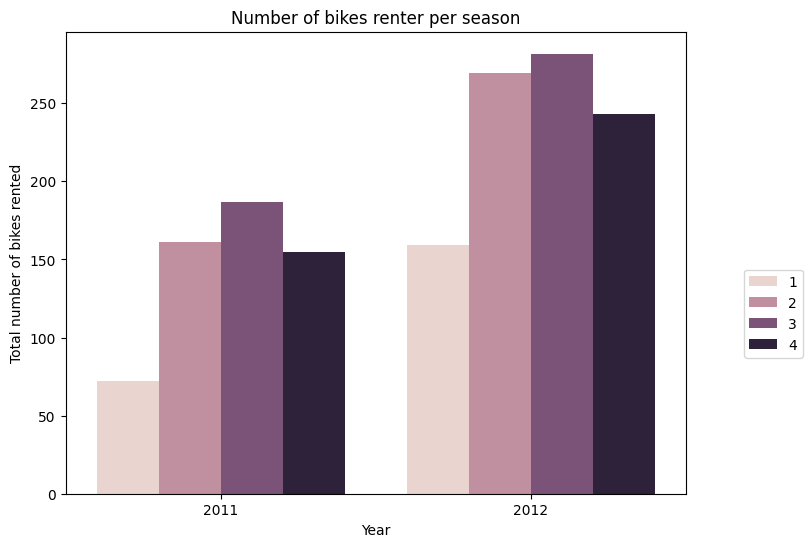

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x='year', y='count', hue='season', data=data, errorbar=None)

plt.legend(loc = 'upper right', bbox_to_anchor= (1.2,0.5))

plt.xlabel('Year')

plt.ylabel('Total number of bikes rented')

plt.title('Number of bikes renter per season')

In [12]:
season_mapping = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter' # Assuming 4 is Winter based on common season numbering
}
data['seasonName'] = data['season'].map(season_mapping)

print(data[['season', 'seasonName']].head())

   season seasonName
0       1     Spring
1       1     Spring
2       1     Spring
3       1     Spring
4       1     Spring


In [15]:
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,seasonName
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,Spring
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,Spring
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,Spring
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,Spring
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,Spring


In [20]:
dataWithSeasonHotEncoded = pd.get_dummies(data, columns=['seasonName'])

dataWithSeasonHotEncoded.sample(5)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,seasonName_Fall,seasonName_Spring,seasonName_Summer,seasonName_Winter
1961,2011-05-08 15:00:00,2,0,0,1,24.60,31.060,49,0.0000,128,230,358,2011,False,False,True,False
1680,2011-04-15 22:00:00,2,1,0,2,15.58,19.695,82,26.0027,16,64,80,2011,False,False,True,False
461,2011-02-02 07:00:00,1,0,1,3,9.02,10.605,93,15.0013,1,48,49,2011,False,True,False,False
7118,2012-04-14 23:00:00,2,0,0,2,22.14,25.760,56,12.9980,45,151,196,2012,False,False,True,False
7479,2012-05-11 00:00:00,2,0,1,1,18.86,22.725,55,7.0015,17,47,64,2012,False,False,True,False


In [23]:
columns = ['holiday','workingday','weather', 'temp','atemp','seasonName_Spring','seasonName_Summer','seasonName_Fall','seasonName_Winter']

features = dataWithSeasonHotEncoded[columns]

features.head()

,holiday,workingday,weather,temp,atemp,seasonName_Spring,seasonName_Summer,seasonName_Fall,seasonName_Winter
0,0,0,1,9.84,14.395,True,False,False,False
1,0,0,1,9.02,13.635,True,False,False,False
2,0,0,1,9.02,13.635,True,False,False,False
3,0,0,1,9.84,14.395,True,False,False,False
4,0,0,1,9.84,14.395,True,False,False,False


In [24]:
target = dataWithSeasonHotEncoded[['count']]

In [26]:
target.head()

,count
0,16
1,40
2,32
3,13
4,1


In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [28]:
x_train

,holiday,workingday,weather,temp,atemp,seasonName_Spring,seasonName_Summer,seasonName_Fall,seasonName_Winter
5743,0,0,1,8.20,9.850,True,False,False,False
7408,0,1,2,21.32,25.000,False,True,False,False
4117,0,1,3,16.40,20.455,False,False,False,True
2281,0,1,1,25.42,31.060,False,True,False,False
8122,0,1,2,25.42,29.545,False,True,False,False
...,...,...,...,...,...,...,...,...,...
6636,0,1,1,26.24,31.060,True,False,False,False
10234,0,0,1,18.04,21.970,False,False,False,True
5092,0,1,2,18.04,21.970,False,False,False,True
6852,0,1,1,22.96,26.515,False,True,False,False


In [29]:
x_test

,holiday,workingday,weather,temp,atemp,seasonName_Spring,seasonName_Summer,seasonName_Fall,seasonName_Winter
3483,0,1,2,24.60,27.275,False,False,True,False
10722,0,1,2,10.66,12.880,False,False,False,True
4303,0,1,2,22.96,26.515,False,False,False,True
8085,0,0,1,21.32,25.000,False,True,False,False
777,0,1,1,11.48,14.395,True,False,False,False
...,...,...,...,...,...,...,...,...,...
8268,0,1,1,34.44,38.635,False,False,True,False
5850,0,1,1,6.56,6.820,True,False,False,False
1902,0,1,1,14.76,18.180,False,True,False,False
3019,0,1,1,30.34,32.575,False,False,True,False


In [37]:
x_train_tensor = torch.from_numpy(x_train.values.astype(float))
x_test_tensor = torch.from_numpy(x_test.values.astype(float))
y_train_tensor = torch.from_numpy(y_train.values.astype(float))
y_test_tensor = torch.from_numpy(y_test.values.astype(float))

In [39]:
x_train_tensor.shape

torch.Size([8708, 9])

In [40]:
import torch.utils.data as data_utils

In [42]:
train_data = data_utils.TensorDataset(x_train_tensor, y_train_tensor)
train_data

In [46]:
train_loader = data_utils.DataLoader(train_data, batch_size=100, shuffle=True)

In [47]:
len(train_loader)

88

In [49]:
features_batch, target_batch = next(iter(train_loader))

In [50]:
features_batch.shape

torch.Size([100, 9])

In [52]:
inp = x_train_tensor.shape[1]

In [53]:
out  = 1

In [54]:
hid  = 10

In [55]:
loss_fn = torch.nn.MSELoss()

In [56]:
model = torch.nn.Sequential(torch.nn.Linear(inp,hid), torch.nn.Linear(hid, out))

In [58]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [62]:
total_step = len(train_loader)
epochs = 2000
for epoch in range(epochs + 1):
    for i, (features_batch, target_batch) in enumerate(train_loader):

        # Forward pass
        output = model(features_batch.float())

        # Calculate the loss
        loss = loss_fn(output, target_batch.float())

        # Zero the gradients
        optimizer.zero_grad()

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    if (epoch) % 2 == 0:
        print('Epoch [{}/{}], Step[{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, i+1, total_step, loss.item()))

print("Training complete!")

Epoch [1/2000], Step[88/88], Loss: 15076.3076
Epoch [3/2000], Step[88/88], Loss: 32194.8828
Epoch [5/2000], Step[88/88], Loss: 25630.2695
Epoch [7/2000], Step[88/88], Loss: 16518.6680
Epoch [9/2000], Step[88/88], Loss: 45791.5430
Epoch [11/2000], Step[88/88], Loss: 49136.5859
Epoch [13/2000], Step[88/88], Loss: 14815.5303
Epoch [15/2000], Step[88/88], Loss: 37639.2422
Epoch [17/2000], Step[88/88], Loss: 49744.2656
Epoch [19/2000], Step[88/88], Loss: 20322.0293
Epoch [21/2000], Step[88/88], Loss: 58770.1484
Epoch [23/2000], Step[88/88], Loss: 30007.8145
Epoch [25/2000], Step[88/88], Loss: 23901.1602
Epoch [27/2000], Step[88/88], Loss: 13865.7900
Epoch [29/2000], Step[88/88], Loss: 9916.5801
Epoch [31/2000], Step[88/88], Loss: 50468.6797
Epoch [33/2000], Step[88/88], Loss: 17345.5156
Epoch [35/2000], Step[88/88], Loss: 13902.7158
Epoch [37/2000], Step[88/88], Loss: 17459.7461
Epoch [39/2000], Step[88/88], Loss: 65721.5156
Epoch [41/2000], Step[88/88], Loss: 8695.8242
Epoch [43/2000], Ste

In [63]:
model.eval()

with torch.no_grad():
    y_pred = model(x_test_tensor.float())

In [64]:
sample = x_test.iloc[45]
sample

,7633
holiday,0
workingday,1
weather,1
temp,22.96
atemp,26.515
seasonName_Spring,False
seasonName_Summer,True
seasonName_Fall,False
seasonName_Winter,False


In [65]:
sample_tensor = torch.tensor(sample.values.astype(float))
sample_tensor

tensor([ 0.0000,  1.0000,  1.0000, 22.9600, 26.5150,  0.0000,  1.0000,  0.0000,
         0.0000], dtype=torch.float64)

In [67]:
with torch.no_grad():
  y_pred = model(sample_tensor.float())

print("Predicted count:", (y_pred.item()))
print("Actual count:", (y_test.iloc[45]))

Predicted count: 230.86453247070312
Actual count: count    205
Name: 7633, dtype: int64
